1. Data Import and Cleaning:

* Import the dataset using Pandas.
* Identify missing values and handle them appropriately.
* Use NumPy to convert relevant columns to numerical types if necessary.

In [24]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [10]:
# Load the dataset using Pandas 
global_powerplant_df_raw = pd.read_csv('global_power_plant_database.csv')

# Preview the first few rows 
global_powerplant_df_raw.head(10)

C:\Users\chery\AppData\Local\Temp\ipykernel_12004\2869072831.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  global_powerplant_df_raw = pd.read_csv('global_power_plant_database.csv')


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.00,31.6700,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.00,31.6230,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
5,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,58.77,54.42,42.71,59.72,46.12,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
6,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION
7,AFG,Afghanistan,Pul-e-Khumri Hydroelectric Power Plant Afghani...,GEODB0040537,6.00,35.9416,68.7100,Hydro,NaN,NaN,...,21.99,21.19,18.40,25.34,19.74,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
8,AFG,Afghanistan,Sarobi Dam Hydroelectric Power Plant Afghanistan,GEODB0040535,22.00,34.5865,69.7757,Hydro,NaN,NaN,...,123.23,82.87,69.15,93.83,80.00,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
9,ALB,Albania,Bistrica 1,WRI1002169,27.00,39.9116,20.1047,Hydro,NaN,NaN,...,105.17,75.26,79.50,105.45,88.45,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [11]:
global_powerplant_df_raw.shape

(34936, 36)

In [12]:
global_powerplant_df_raw.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [13]:
print(global_powerplant_df_raw.isnull().sum())
print(global_powerplant_df_raw.shape)

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh_2019               25277


In [14]:
# Drop columns where 95% of the data is missing
cols_to_drop = ['other_fuel1', 'other_fuel2', 'other_fuel3']
global_powerplant_df = global_powerplant_df_raw.drop(columns=cols_to_drop)

# Commissioning year can be used for a time analysis, but 50% of data is missing. Fill in the missing 50% with the median value
median_year = global_powerplant_df['commissioning_year'].median()
global_powerplant_df['commissioning_year'] = global_powerplant_df['commissioning_year'].fillna(median_year)

In [16]:
# For the generation_gwh_201x columns, average them (of their available data). 
# Since individually they each are missing a significant portion of their values, a single average column will be more representative

# Define columns to average
gen_cols =  [
    'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 
    'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 
    'generation_gwh_2019'
]

# Calculate avg across those columns
# axis=1 ensures we average horizontally (for each plant, not vertically for each year across plants)
# nanmean ignores the NaNs rather than letthing them ruin the calculation
global_powerplant_df['avg_generation_13_19'] = np.nanmean(global_powerplant_df[gen_cols].values, axis=1)

global_powerplant_df = global_powerplant_df.drop(columns=gen_cols)

C:\Users\chery\AppData\Local\Temp\ipykernel_12004\755407364.py:14: RuntimeWarning: Mean of empty slice
  global_powerplant_df['avg_generation_13_19'] = np.nanmean(global_powerplant_df[gen_cols].values, axis=1)


In [18]:
global_powerplant_df.isnull().sum()

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
commissioning_year                    0
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_data_source            23536
estimated_generation_gwh_2013     18816
estimated_generation_gwh_2014     18433
estimated_generation_gwh_2015     17886
estimated_generation_gwh_2016     17366
estimated_generation_gwh_2017      1798
estimated_generation_note_2013        0
estimated_generation_note_2014        0
estimated_generation_note_2015        0
estimated_generation_note_2016        0


In [ ]:
global_powerplant_df.isnull().sum()

In [19]:
# Drop admin columns, not useful for trends and analysis
meta_cols_to_drop = [
    'owner', 'source', 'url', 'geolocation_source', 
    'wepp_id', 'year_of_capacity_data', 'generation_data_source'
]

global_powerplant_df = global_powerplant_df.drop(columns=meta_cols_to_drop)

In [20]:
global_powerplant_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   commissioning_year              34936 non-null  float64
 9   estimated_generation_gwh_2013   16120 non-null  float64
 10  estimated_generation_gwh_2014   16503 non-null  float64
 11  estimated_generation_gwh_2015   17050 non-null  float64
 12  estimated_generation_gwh_2016   

In [21]:
global_powerplant_df.isnull().sum()

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
commissioning_year                    0
estimated_generation_gwh_2013     18816
estimated_generation_gwh_2014     18433
estimated_generation_gwh_2015     17886
estimated_generation_gwh_2016     17366
estimated_generation_gwh_2017      1798
estimated_generation_note_2013        0
estimated_generation_note_2014        0
estimated_generation_note_2015        0
estimated_generation_note_2016        0
estimated_generation_note_2017        0
avg_generation_13_19              23536
dtype: int64

In [22]:
# For the estimated generation columns, focus on 2017 for the statistical analysis since it has the fewest amount of missing values. 
est_cols_to_drop = [
    'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 
    'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016'
]

global_powerplant_df = global_powerplant_df.drop(columns=est_cols_to_drop)

# Rename 2017 for clarity
global_powerplant_df = global_powerplant_df.rename(columns={'estimated_generation_gwh_2017': 'est_gen_2017'})

In [23]:
global_powerplant_df.isnull().sum()

country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
commissioning_year                    0
est_gen_2017                       1798
estimated_generation_note_2013        0
estimated_generation_note_2014        0
estimated_generation_note_2015        0
estimated_generation_note_2016        0
estimated_generation_note_2017        0
avg_generation_13_19              23536
dtype: int64

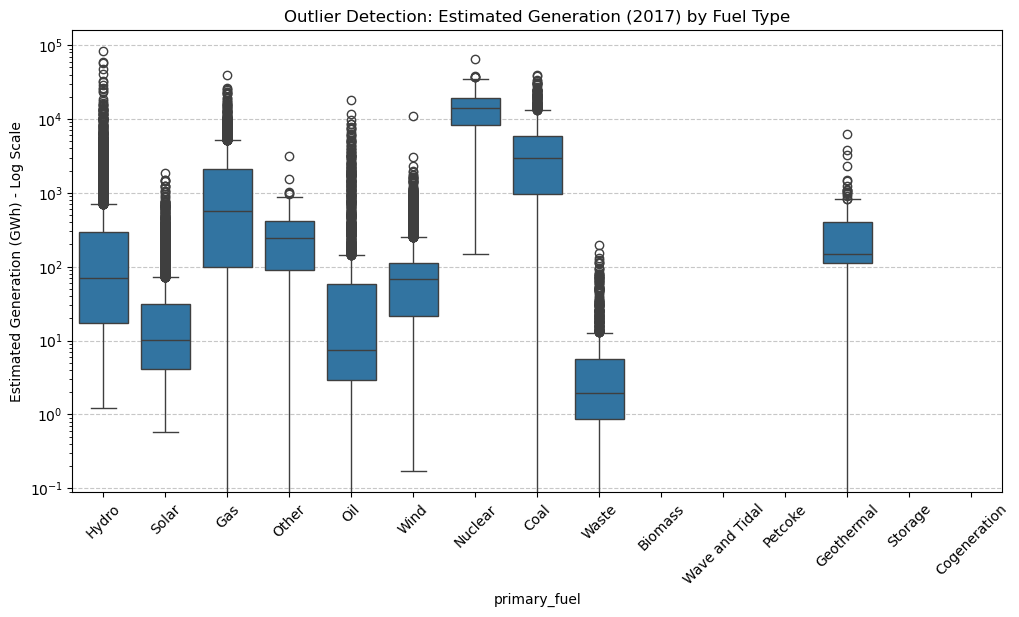

In [25]:
# Before next steps with the est_gen_2017 missing values, lets understand the current values

plt.figure(figsize=(12,6))

sns.boxplot(x='primary_fuel', y='est_gen_2017', data=global_powerplant_df)

plt.yscale('log')

plt.title('Outlier Detection: Estimated Generation (2017) by Fuel Type')
plt.xticks(rotation=45)
plt.ylabel('Estimated Generation (GWh) - Log Scale')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [26]:
# Fill missing values with the median of each fuel category 
# transform() ensures the median of 'Solar' only fills missing 'Solar' rows

global_powerplant_df['est_gen_2017'] = global_powerplant_df.groupby('primary_fuel')['est_gen_2017'].transform(lambda x: x.fillna(x.median()))

# if a fuel type had zero data to begin with, it will still be NaN. Fill the last few with 0. 
global_powerplant_df['est_gen_2017'] = global_powerplant_df['est_gen_2017'].fillna(0)

print(f"Missing values remaining: {global_powerplant_df['est_gen_2017'].isnull().sum}")

Missing values remaining: <bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
34931    False
34932    False
34933    False
34934    False
34935    False
Name: est_gen_2017, Length: 34936, dtype: bool>


2. Exploratory Data Analysis:
* Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.
* Explore the distribution of power plants by country and fuel type.

In [27]:
# Calculate a global summary

numerical_cols = ['capacity_mw', 'est_gen_2017']

global_stats = global_powerplant_df[numerical_cols].agg(['mean', 'median', 'std']).transpose()
print("Global Statistics:\n", global_stats)

Global Statistics:
                     mean  median          std
capacity_mw   163.355148  16.745   489.636072
est_gen_2017  683.366786  32.760  2427.386661


In [28]:
# Summary by fuel type

fuel_stats = global_powerplant_df.groupby('primary_fuel')['capacity_mw'].agg(['mean', 'median', 'std', 'count'])

fuel_stats = fuel_stats.sort_values(by='median', ascending=False)

print("\nStatistics by Fuel Type (Capacity MW):")
print(fuel_stats)


Statistics by Fuel Type (Capacity MW):
                       mean      median          std  count
primary_fuel                                               
Nuclear         2091.855179  1888.00000  1303.509273    195
Coal             843.579828   600.00000   888.187187   2330
Gas              373.449375   147.50000   560.934146   3998
Petcoke          202.048125    65.48875   476.986459     12
Other             84.020000    40.00000   145.891392     43
Cogeneration      98.731707    31.90000   283.428252     41
Geothermal        67.130952    30.00000   114.640890    189
Wind              49.224126    27.00000   106.138355   5344
Hydro            147.171551    20.00000   549.809328   7156
Biomass           23.972938     9.45000    39.461805   1430
Oil              112.878754     9.00000   392.009039   2320
Solar             17.657039     5.80000    41.939412  10665
Wave and Tidal    55.220000     5.00000   101.440708     10
Storage           12.683704     4.90000    35.574631    135


In [29]:
# Distribution by Country (Top 10)

country_dist = global_powerplant_df['country_long'].value_counts().head(10)

print("\nTop 10 Countries by Plant Count:")
print(country_dist)


Top 10 Countries by Plant Count:
country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
India                       1589
Germany                     1309
Canada                      1159
Spain                        829
Russia                       545
Name: count, dtype: int64


In [30]:
# Distribution by Fuel Type
fuel_dist = global_powerplant_df['primary_fuel'].value_counts()

print("\nPlant Counts by Fuel Type: \n", fuel_dist)




Plant Counts by Fuel Type: 
 primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64


3. Statistical Analysis:
* Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
* Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.

In [31]:
# Isolate the capacity data for two major fuel types 
solar_capacity = global_powerplant_df[global_powerplant_df['primary_fuel'] == 'Solar']['capacity_mw'].to_numpy()
hydro_capacity = global_powerplant_df[global_powerplant_df['primary_fuel'] == 'Hydro']['capacity_mw'].to_numpy()

# Perform statistical analysis 
stats = {
    'Solar' : {
        'Mean' : np.mean(solar_capacity),
        'Median' : np.median(solar_capacity),
        'Std Dev' : np.std(solar_capacity),
        'Max' : np.max(solar_capacity),
        'Total Sum' : np.sum(solar_capacity)  
    },
    'Hydro' : {
        'Mean' : np.mean(hydro_capacity),
        'Median' : np.median(hydro_capacity),
        'Std Dev' : np.std(hydro_capacity),
        'Max' : np.max(hydro_capacity),
        'Total Sum' : np.sum(hydro_capacity)  
    } 
}

for fuel, data in stats.items():
    print(f"--- {fuel} Statistics (NumPy) ---")
    for stat, value in data.items():
        print(f"{stat}: {value:.2f}")
    print("\n")

--- Solar Statistics (NumPy) ---
Mean: 17.66
Median: 5.80
Std Dev: 41.94
Max: 1021.00
Total Sum: 188312.32


--- Hydro Statistics (NumPy) ---
Mean: 147.17
Median: 20.00
Std Dev: 549.77
Max: 22500.00
Total Sum: 1053159.62




In [32]:
from scipy import stats

In [33]:
# Null Hypothesis: There is no significant difference in the mean capacity between Solar and Hydro plants
# Alternative Hypothesis: There is a significant difference in the mean capacity between Solar and Hydro plants

solar_data = global_powerplant_df[global_powerplant_df['primary_fuel'] == 'Solar']['capacity_mw'].to_numpy()
hydro_data = global_powerplant_df[global_powerplant_df['primary_fuel'] == 'Hydro']['capacity_mw'].to_numpy()

t_stat, p_value = stats.ttest_ind(solar_data, hydro_data, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value: .4f}")


T-statistic: -19.8882
P-value:  0.0000


Given the p-value below 0.05 we can reject the null hypothesis and conclude that there is a significant difference in the man capacity between solar and hydro plants

4. Time Series Analysis:
* If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.
* Explore how the mix of fuel types for power generation has evolved over the years.

In [34]:
# Group the years into decades 

# Filter for valid years to avoid the median placeholders used earlier
valid_years_mask = (global_powerplant_df['commissioning_year'] >= 1960) & global_powerplant_df['commissioning_year'] <= 2024
time_df = global_powerplant_df[valid_years_mask].copy()

# Group the years into decades
time_df['decade'] = (time_df['commissioning_year'] // 10 * 10).astype(int)

# count of how many of each fuel type were built per decade
evolution = time_df.groupby(['decade', 'primary_fuel']).size().unstack(fill_value=0)
evolution_pct = evolution.div(evolution.sum(axis=1), axis=0) * 100

print("Fuel Mix Evolution (% of new plants per decade):")
print(evolution_pct.tail(5))

Fuel Mix Evolution (% of new plants per decade):
primary_fuel   Biomass       Coal  Cogeneration        Gas  Geothermal  \
decade                                                                   
1980          3.505155  14.020619      0.481100  19.243986    1.855670   
1990          3.685504  14.127764      0.491400  30.159705    2.579853   
2000          5.017804   4.628936      0.060907  10.152736    0.370127   
2010          2.684564   7.802013      0.097875   7.885906    0.433445   
2020          0.666667   0.000000      0.000000   4.000000    0.000000   

primary_fuel      Hydro   Nuclear        Oil     Other   Petcoke      Solar  \
decade                                                                        
1980          36.838488  3.298969  10.721649  0.274914  0.412371   0.343643   
1990          22.788698  0.307125  14.803440  0.245700  0.122850   0.122850   
2000          17.911357  0.482571   5.640930  0.093703  0.004685  33.854948   
2010           7.312640  0.055928   5

From the data we can see that renewable energy, like solar and wind start going up in the 2000s. We can also see a decline in coal and oil in the 2000s. 

In [ ]:
#Since I have filled missing values with the median, we are going to filter them out so as not to skew the analysis

current_median = global_powerplant_df['commissioning_year'].median()
print(f"Your median placeholder is {current_median}")

real_trends_df = global_powerplant_df[(global_powerplant_df['commissioning_year'] >= 1960) & 
                                      (global_powerplant_df['commissioning_year'] != current_median)
                                      ]

real_trends_df['decade'] = (real_trends_df['commissioning_year'] // 10 * 10).astype(int)

# count of how many of each fuel type were built per decade
evolution = real_trends_df.groupby(['decade', 'primary_fuel']).size().unstack(fill_value=0)
evolution_pct = evolution.div(evolution.sum(axis=1), axis=0) * 100

print("Fuel Mix Evolution (% of new plants per decade):")
print(evolution_pct.tail(5))

Your median placeholder is 2007.0
Fuel Mix Evolution (% of new plants per decade):
primary_fuel   Biomass       Coal  Cogeneration        Gas  Geothermal  \
decade                                                                   
1980          3.505155  14.020619      0.481100  19.243986    1.855670   
1990          3.685504  14.127764      0.491400  30.159705    2.579853   
2000          5.912596  13.567552      0.171380  24.792916    0.885461   
2010          2.684564   7.802013      0.097875   7.885906    0.433445   
2020          0.666667   0.000000      0.000000   4.000000    0.000000   

primary_fuel      Hydro   Nuclear        Oil     Other   Petcoke      Solar  \
decade                                                                        
1980          36.838488  3.298969  10.721649  0.274914  0.412371   0.343643   
1990          22.788698  0.307125  14.803440  0.245700  0.122850   0.122850   
2000          11.796630  0.171380  13.053413  0.114253  0.000000   1.570980   
201

C:\Users\chery\AppData\Local\Temp\ipykernel_12004\409478102.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_trends_df['decade'] = (real_trends_df['commissioning_year'] // 10 * 10).astype(int)


5. Advanced Visualization:
* Create visualizations using Matplotlib and Seaborn to illustrate your findings.
* Consider plotting the geographical distribution of power plants using latitude and longitude data, if available.

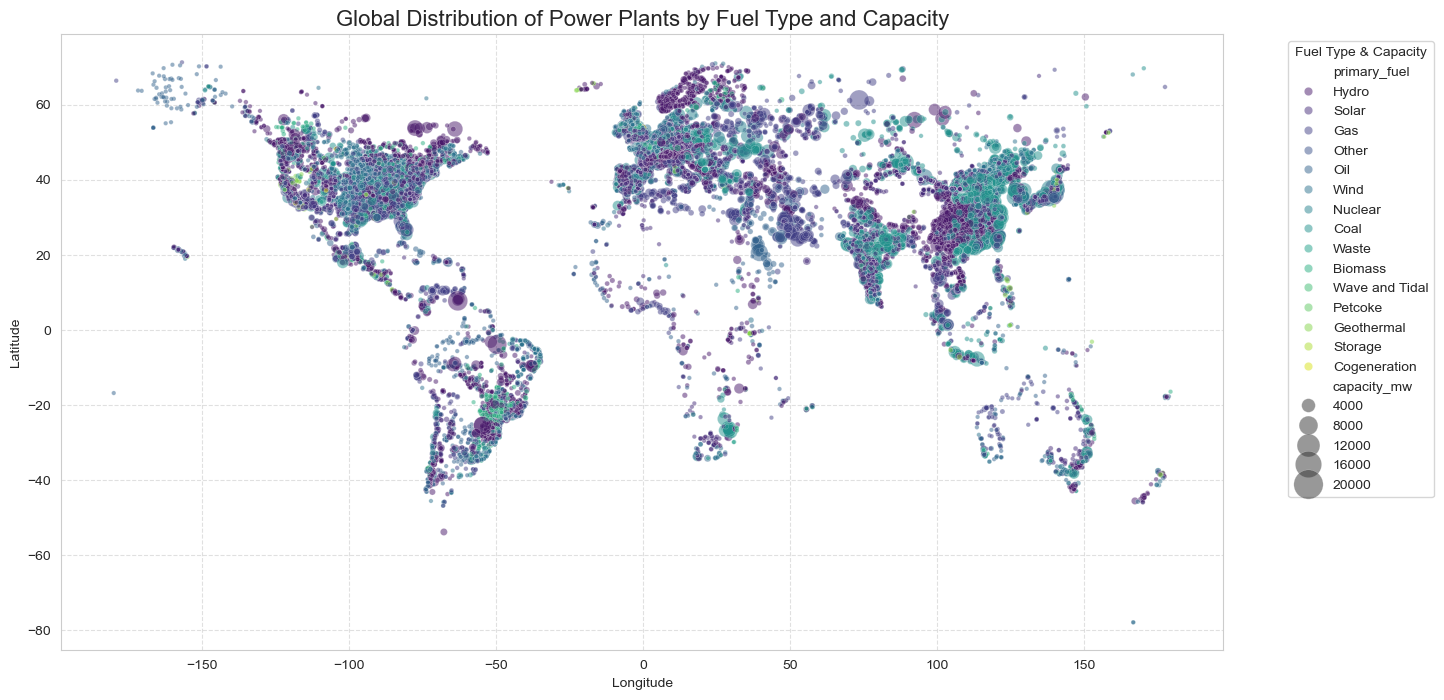

In [38]:
sns.set_style("whitegrid")

plt.figure(figsize=(15,8))

# Create the scatterplot
map_plot = sns.scatterplot(
    data=global_powerplant_df,
    x='longitude',
    y='latitude',
    hue='primary_fuel',
    size='capacity_mw',
    sizes=(10, 500),
    alpha=0.5,
    palette='viridis'
)

plt.title('Global Distribution of Power Plants by Fuel Type and Capacity', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Fuel Type & Capacity')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

6. Matrix Operations in Real-World Context:
* Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
* Discuss the relevance of eigenvectors and eigenvalues in this context.

In [39]:
# Select numerical columns for analysis 
matrix_cols = ['capacity_mw', 'latitude', 'longitude', 'est_gen_2017']
matrix_data = global_powerplant_df[matrix_cols].dropna().to_numpy()

# Standardize the data
standardized_data = (matrix_data - np.mean(matrix_data, axis=0)) / np.std(matrix_data, axis=0)

# Calculate the covariance matrix to show how much each variable changes in relation to the others
cov_matrix = np.cov(standardized_data.T)

print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00002862 -0.01321797  0.15152887  0.94607269]
 [-0.01321797  1.00002862 -0.06835636 -0.01387432]
 [ 0.15152887 -0.06835636  1.00002862  0.145785  ]
 [ 0.94607269 -0.01387432  0.145785    1.00002862]]


In [40]:
eigen_values, eigen_vecs = np.linalg.eig(cov_matrix)

print(f"\nEigenvalues: {eigen_values}")


Eigenvalues: [1.99181254 0.05393745 0.9106712  1.04369331]


Eigenvectors represent the ...

In [41]:
# Select top 5 fuel types 
top_fuels = global_powerplant_df['primary_fuel'].value_counts().nlargest(5).index
df_subset = global_powerplant_df[global_powerplant_df['primary_fuel'].isin(top_fuels)].copy()

# One hot encode the fuel types 
fuel_dummies = pd.get_dummies(df_subset['primary_fuel'])

# Create matrix
feature_matrix = np.hstack([
    df_subset[['capacity_mw']].to_numpy(),
    fuel_dummies.to_numpy()
])

# Standardize the matrix
standardized_matrix = (feature_matrix - np.mean(feature_matrix, axis=0)) / np.std(feature_matrix, axis=0)

print(f"Matrix Shape: {standardized_matrix.shape}")

Matrix Shape: (29493, 6)


7. Integrating NumPy with Pandas and Matplotlib:
* Show how NumPy can be used to enhance data manipulation in Pandas and data visualization in Matplotlib.
* Provide examples, such as using NumPy arrays for complex filtering in Pandas or for creating sophisticated plots in Matplotlib.


In [43]:
# Filtering with np.select

conditions = [
    (global_powerplant_df['capacity_mw'] < 10),
    (global_powerplant_df['capacity_mw'] >= 10) & (global_powerplant_df['capacity_mw'] < 100),
    (global_powerplant_df['capacity_mw'] >= 100) & (global_powerplant_df['capacity_mw'] < 1000),
    (global_powerplant_df['capacity_mw'] >= 1000)
]

# Define the labels (The Results)
choices = ['Micro', 'Small', 'Medium', 'Mega']

# Use NumPy to create the new column in Pandas
global_powerplant_df['size_category'] = np.select(conditions, choices, default='Unknown')

print(global_powerplant_df[['name', 'capacity_mw', 'size_category']].head())

                                               name  capacity_mw size_category
0      Kajaki Hydroelectric Power Plant Afghanistan         33.0         Small
1                                      Kandahar DOG         10.0         Small
2                                      Kandahar JOL         10.0         Small
3     Mahipar Hydroelectric Power Plant Afghanistan         66.0         Small
4  Naghlu Dam Hydroelectric Power Plant Afghanistan        100.0        Medium


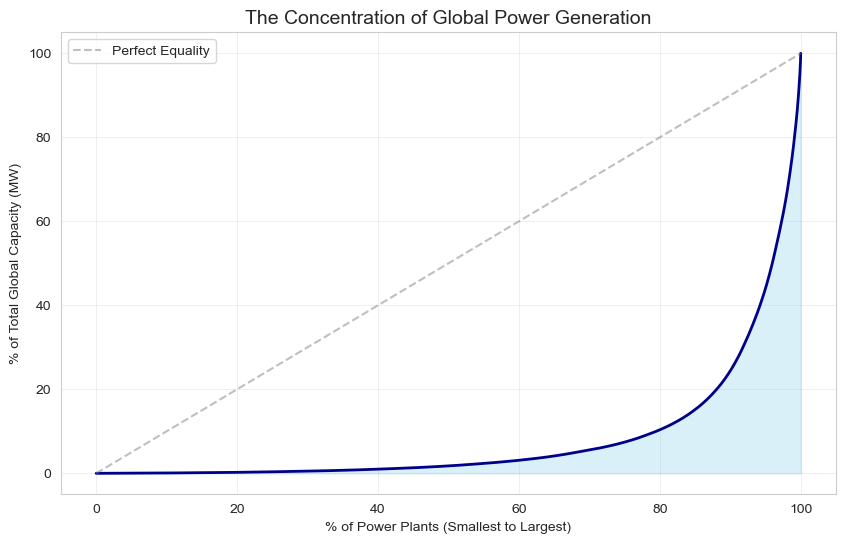

In [44]:
# Use Numpy to calculate a Cumulative Distribution Function (CDF)

# 1. Use NumPy to sort and calculate cumulative capacity
sorted_capacities = np.sort(global_powerplant_df['capacity_mw'].to_numpy())
cumulative_capacity = np.cumsum(sorted_capacities)

# 2. Normalize the data (0 to 100%)
# This turns the data into a "Percentage of Total World Power"
percent_of_plants = np.linspace(0, 100, len(sorted_capacities))
percent_of_power = (cumulative_capacity / np.sum(sorted_capacities)) * 100

# 3. Plot with Matplotlib
plt.figure(figsize=(10, 6))
plt.plot(percent_of_plants, percent_of_power, color='darkblue', linewidth=2)

# Add a 50/50 reference line for comparison
plt.plot([0, 100], [0, 100], linestyle='--', color='gray', alpha=0.5, label='Perfect Equality')

plt.title('The Concentration of Global Power Generation', fontsize=14)
plt.xlabel('% of Power Plants (Smallest to Largest)')
plt.ylabel('% of Total Global Capacity (MW)')
plt.fill_between(percent_of_plants, percent_of_power, color='skyblue', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()